[INFO] Loaded config_str: {'rows': '2000', 'num_tx': '10', 'update_ratio': '5.0', 'seed': '2333333', 'bucket_num': '128'}
=== Building Rust binary in release mode ===
Cargo build completed successfully.


=== hash_type=chain ===
   iteration 1/1

=== hash_type=heap ===
   iteration 1/1

=== hash_type=linear ===
   iteration 1/1

=== hash_type=partition ===
   iteration 1/1
op_with_type: ('Insert', 'chain'), durations_list: ['1.463505ms', '1.16578ms', '1.083453ms']

op_with_type: ('Update', 'chain'), durations_list: ['2.286847ms', '2.442515ms', '2.521816ms', '2.607851ms', '2.784453ms', '2.818499ms', '2.928739ms', '3.100456ms', '3.992377ms', '1.916436ms', '1.959093ms', '2.007134ms', '2.102491ms', '2.332296ms', '2.430534ms', '2.651962ms', '3.007274ms', '3.018877ms', '1.790299ms', '1.887104ms', '2.006035ms', '2.060067ms', '2.201078ms', '2.32182ms', '2.564419ms', '3.038542ms', '3.059024ms']

op_with_type: ('Scan-Recent', 'chain'), durations_list: ['2.757µs', '2.114µs', '1.571µs', '1.516µs',

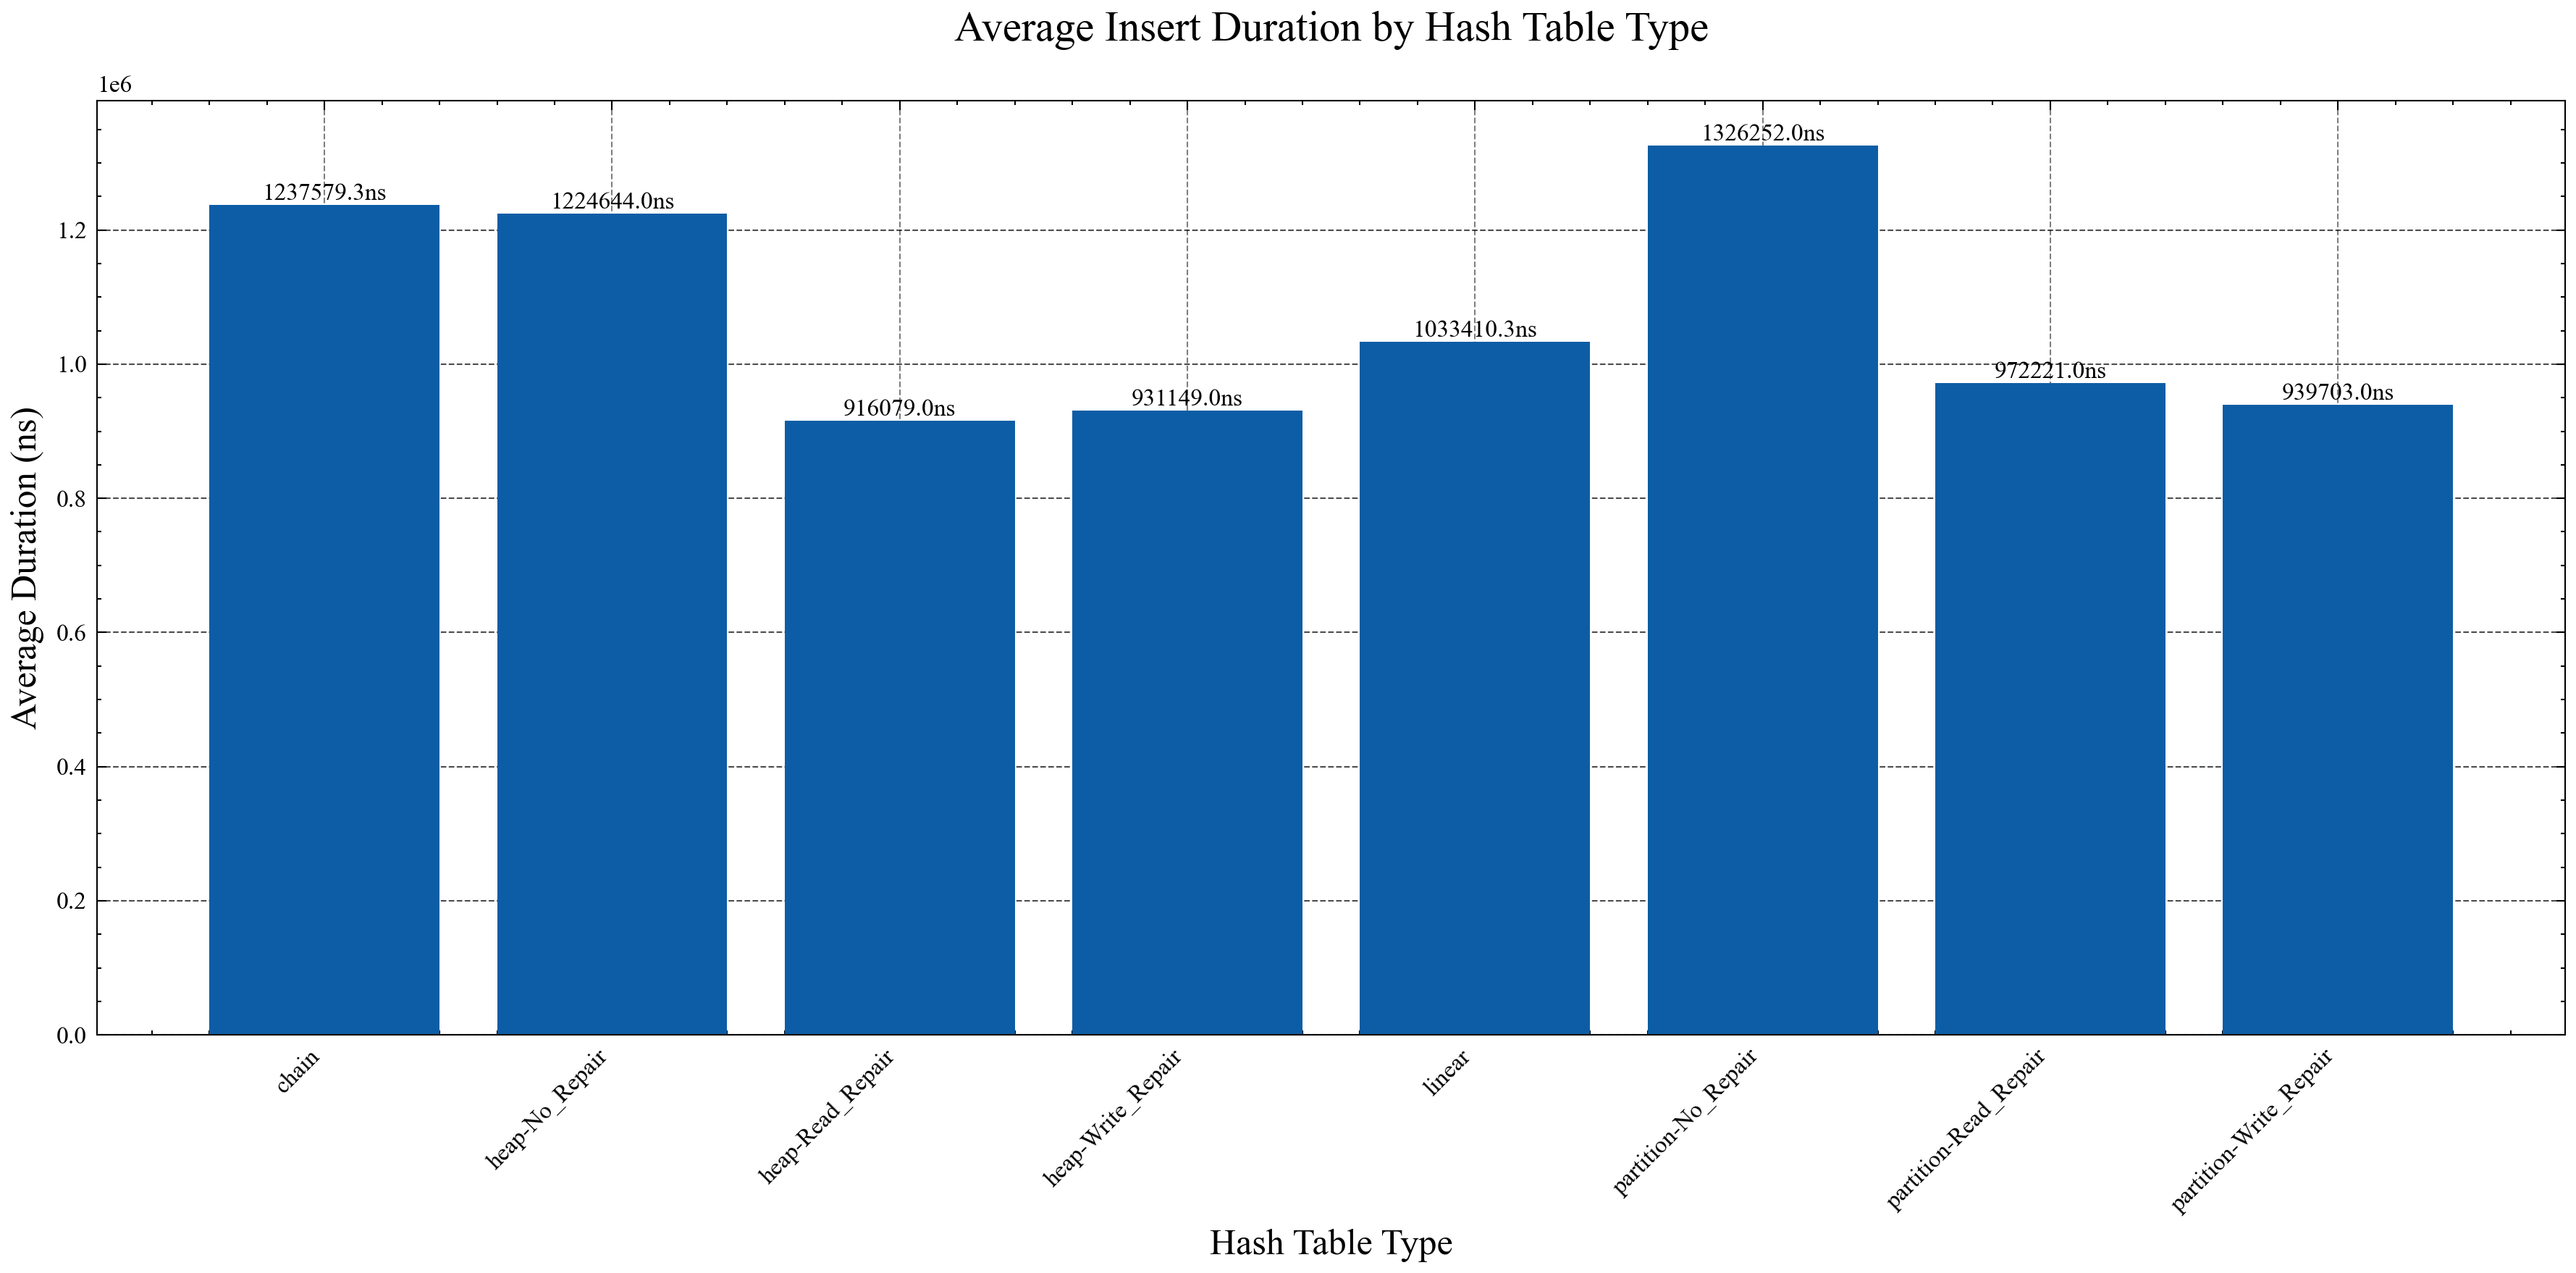

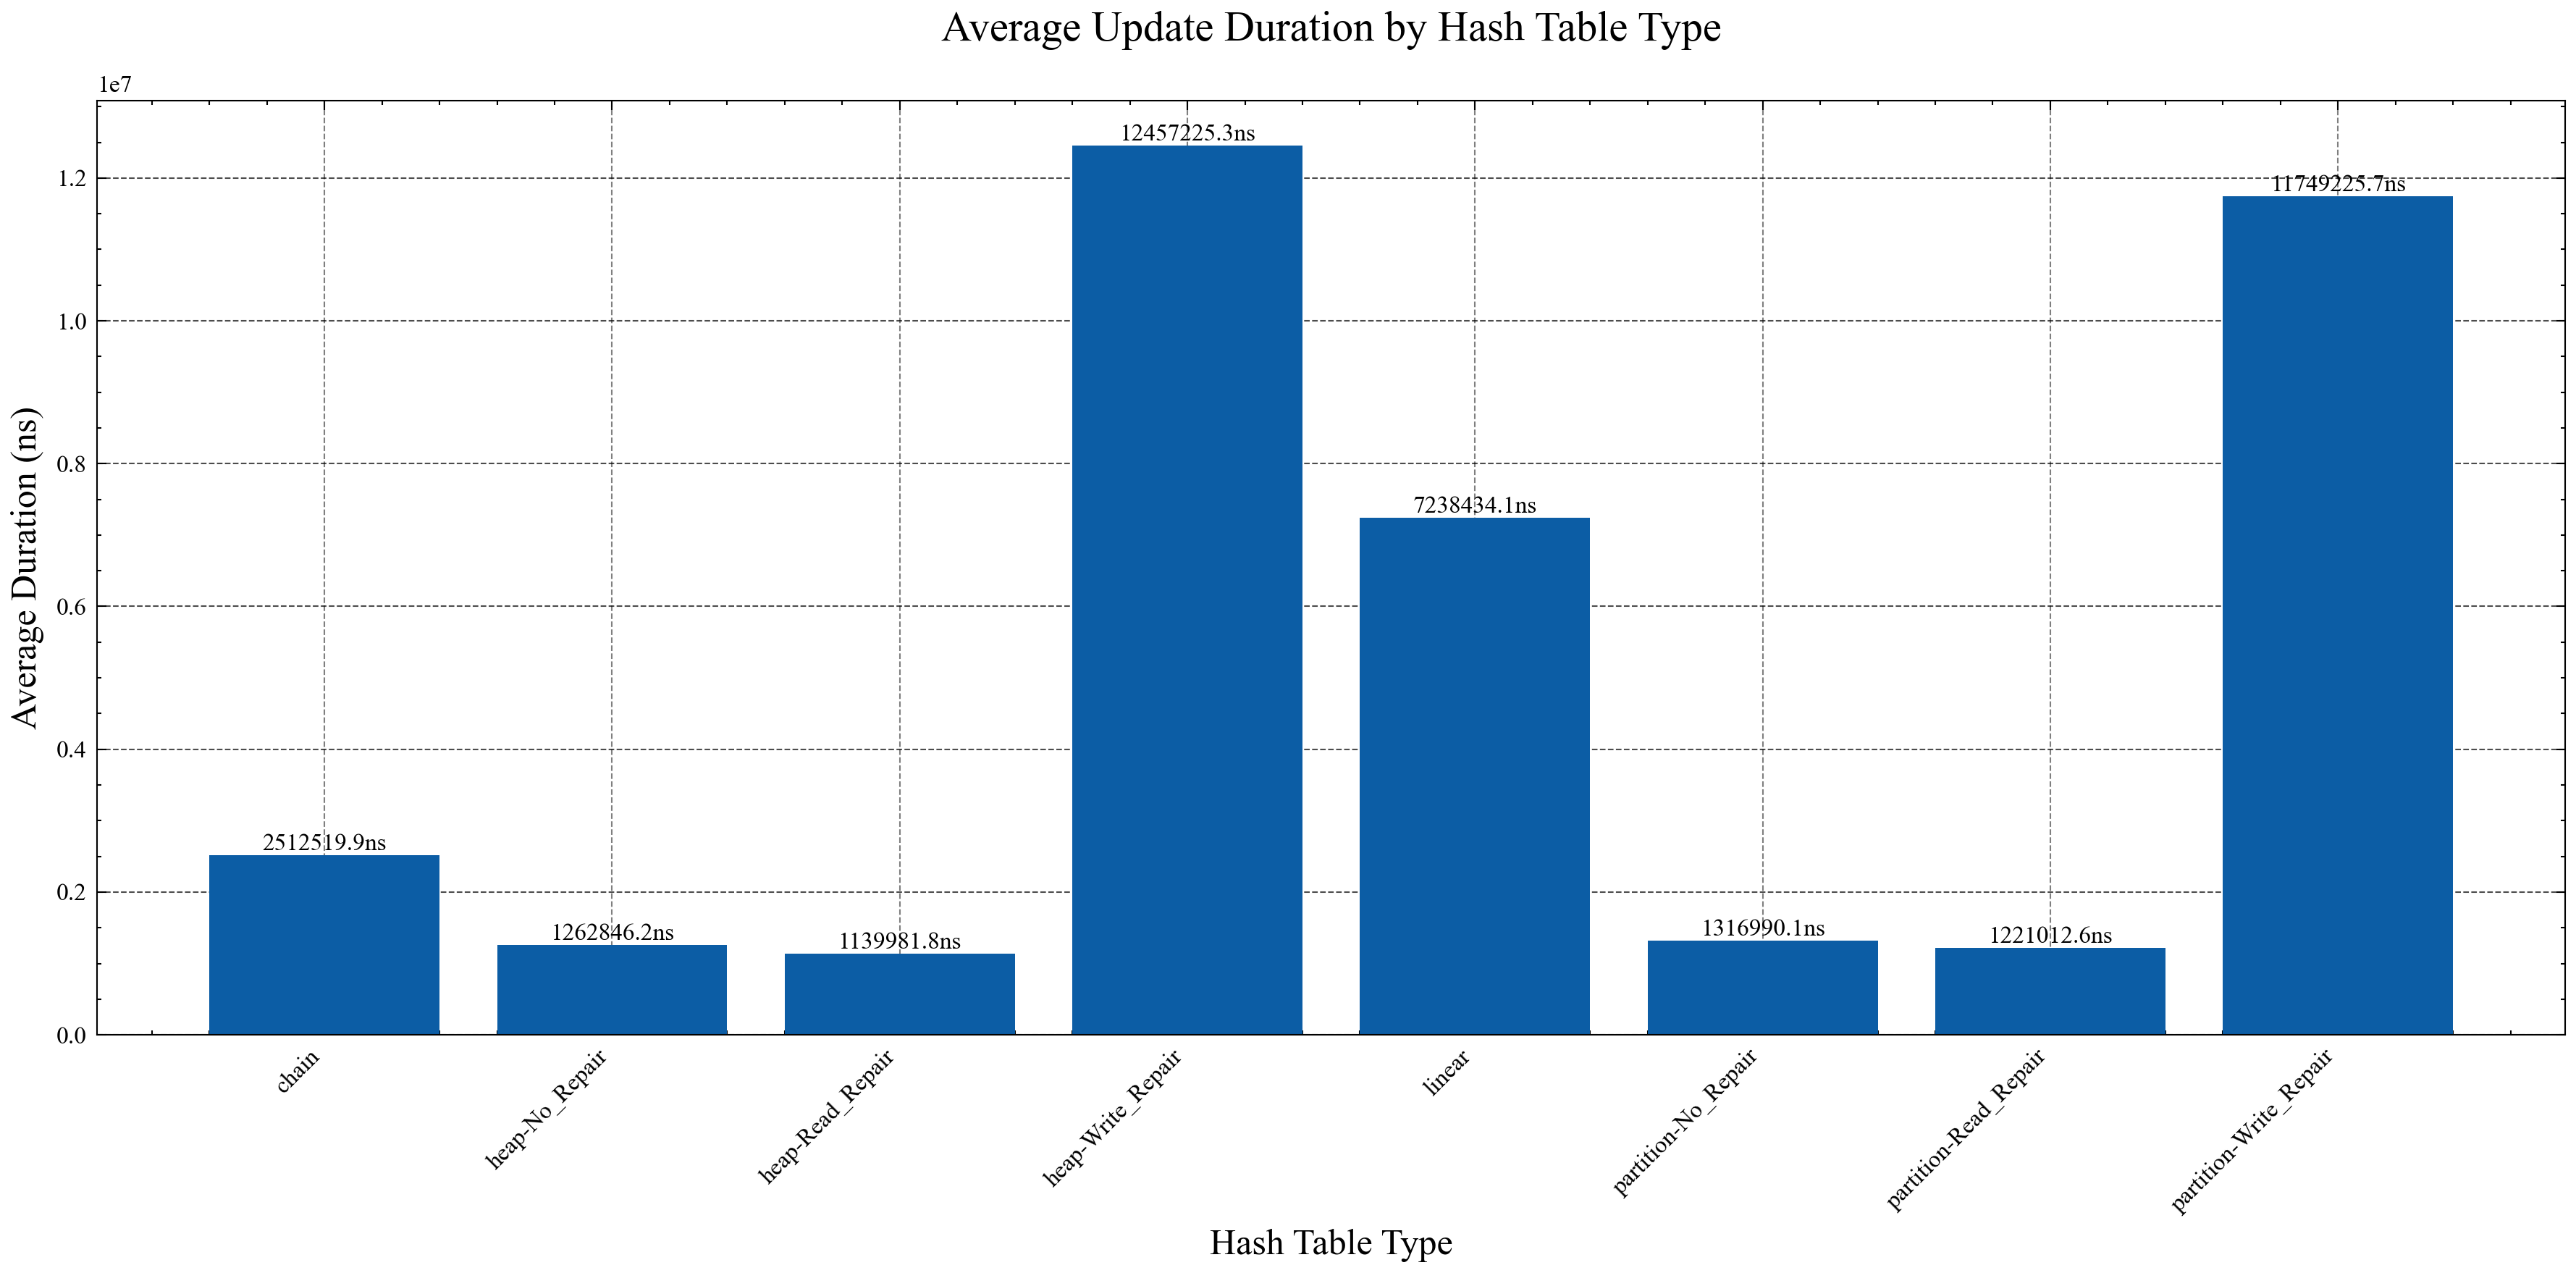

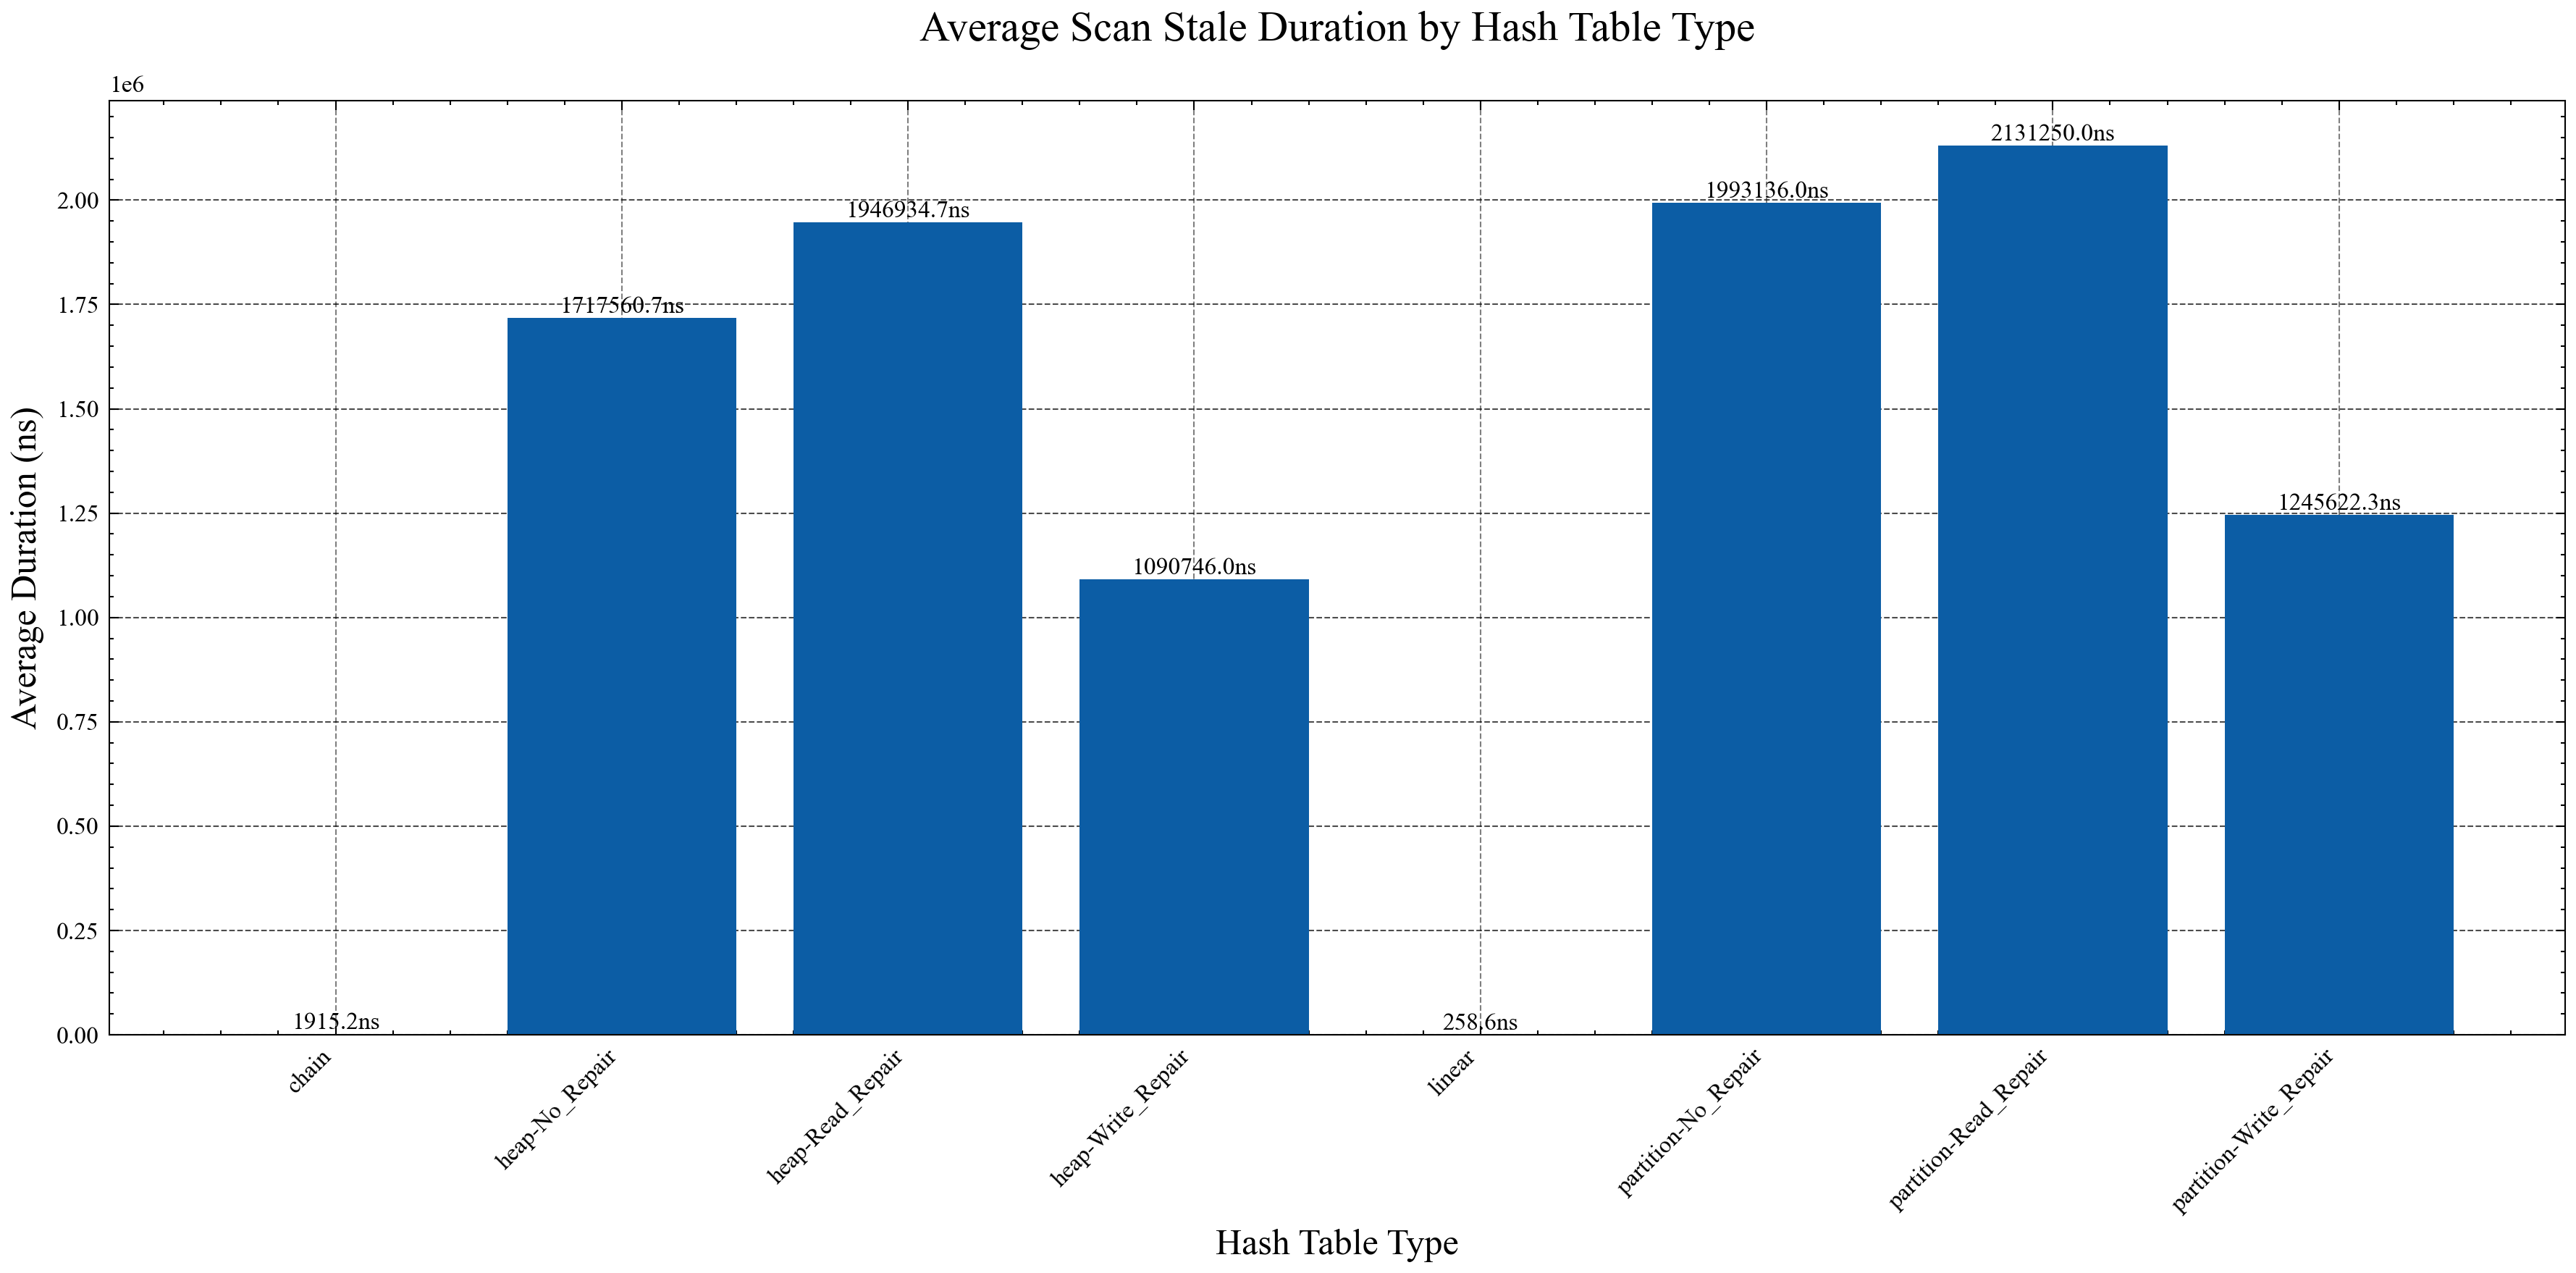

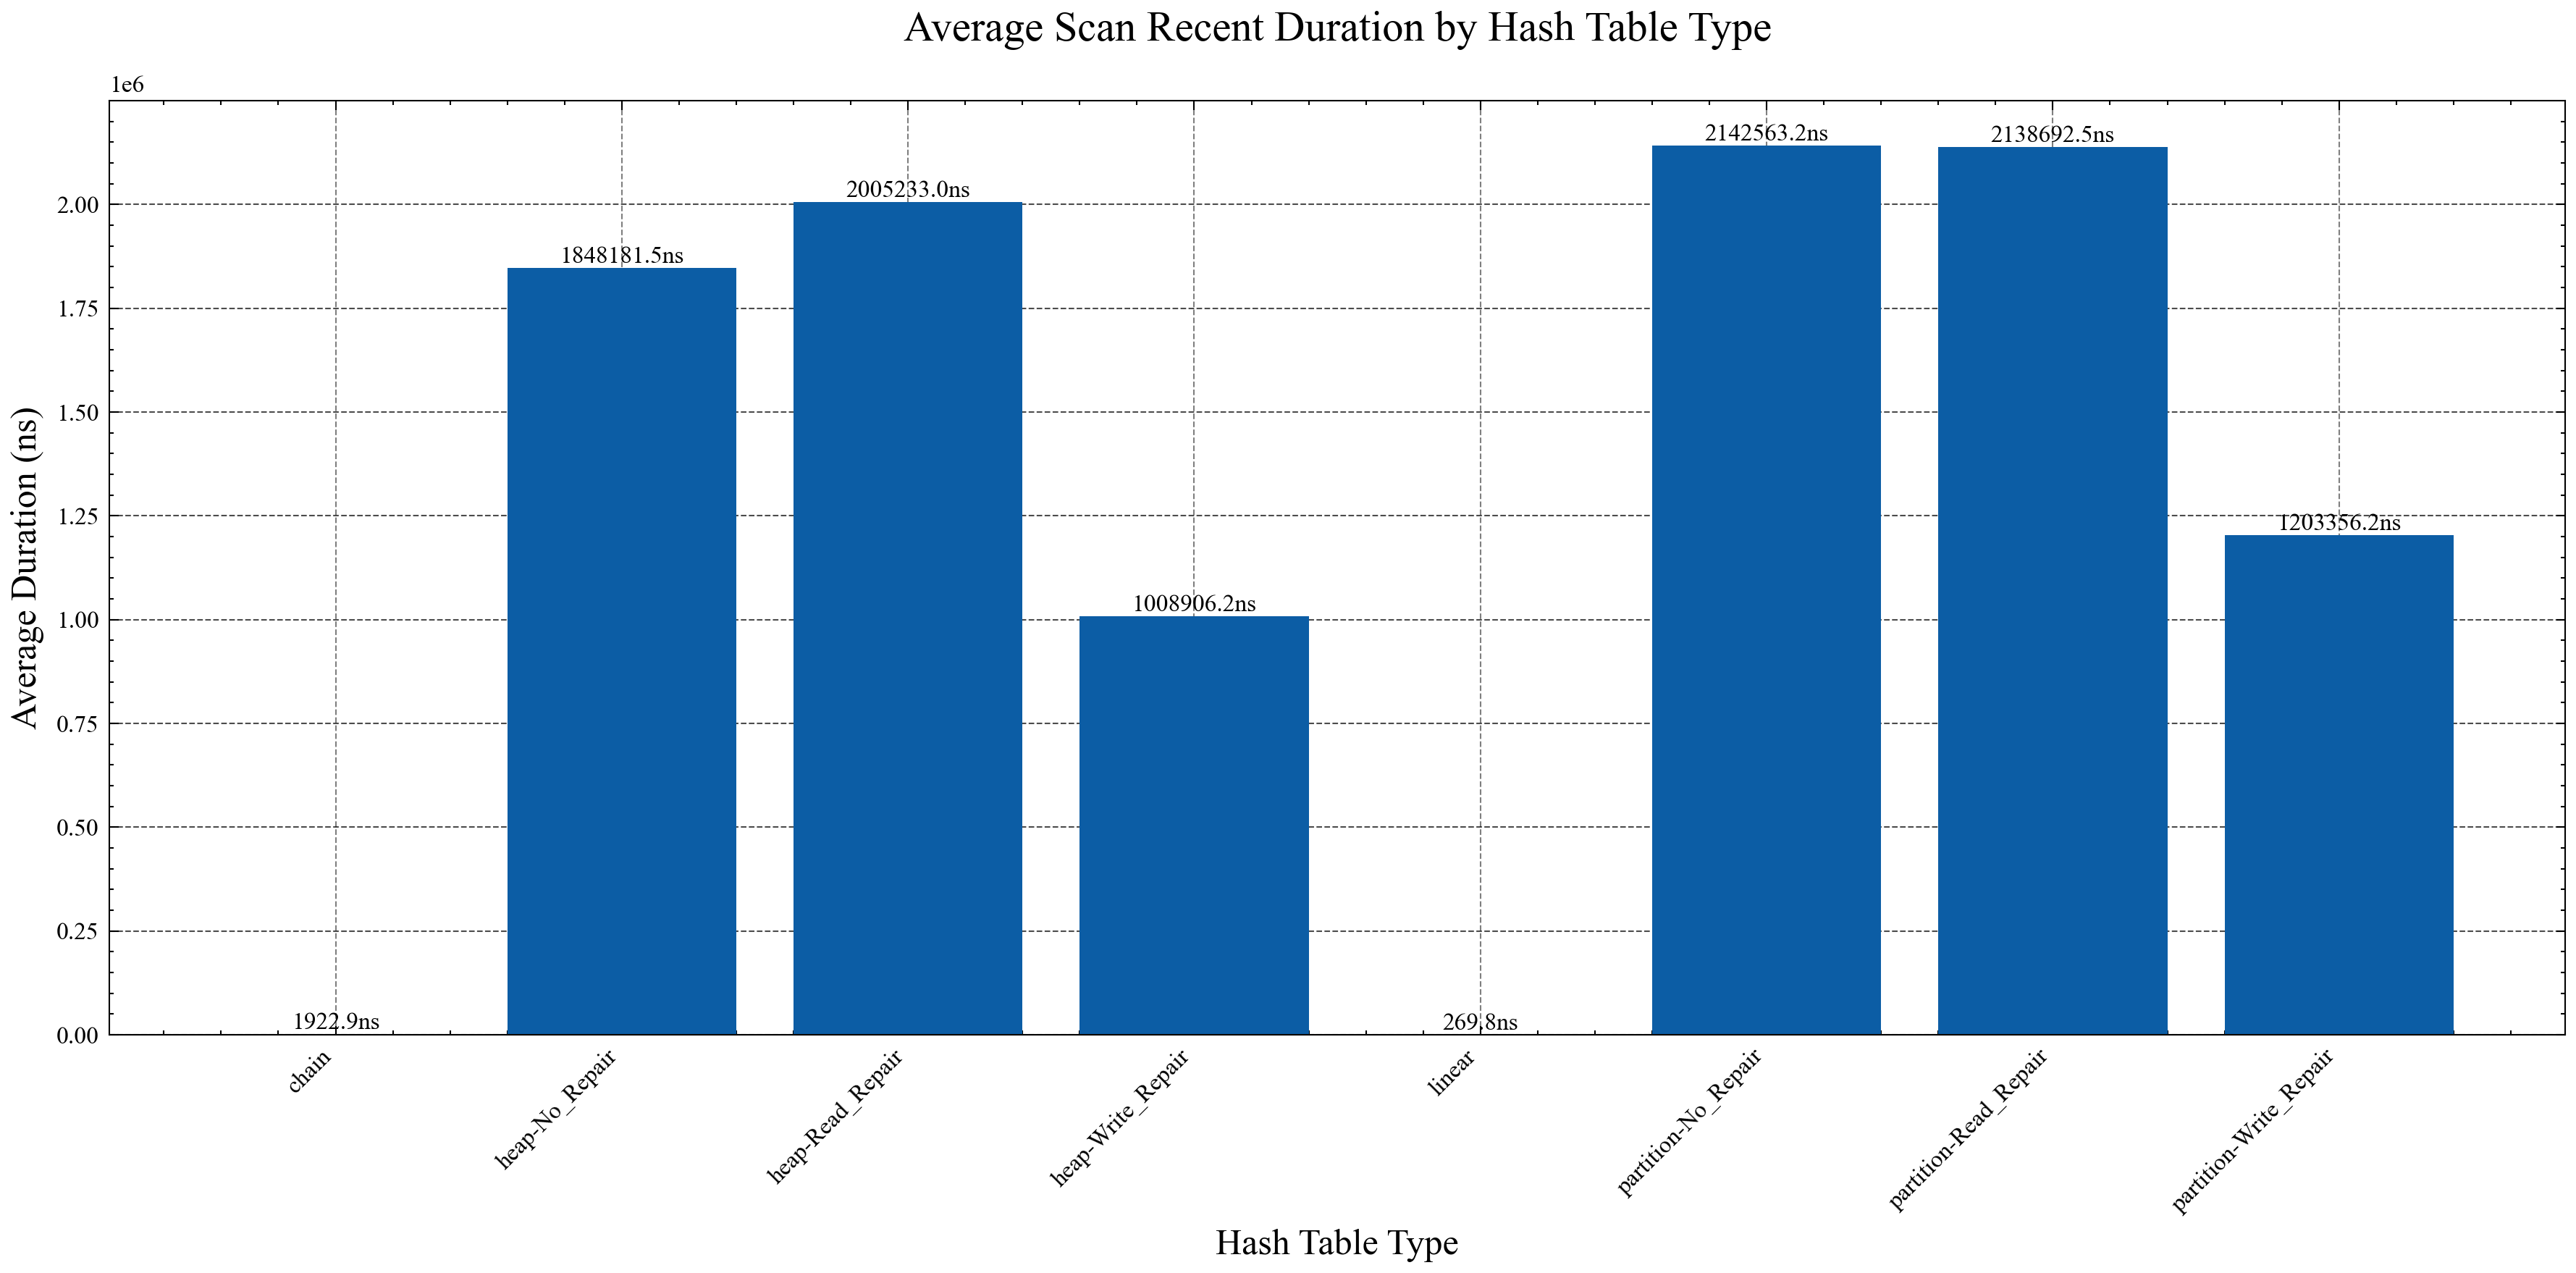

In [1]:
import subprocess
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import copy

seed = 2333333

DEFAULT_CFG = {
    "rows": "2000",
    "num_tx": "10",
    "update_ratio": "5.0",
    "seed": str(seed),
    "bucket_num": "128",
}



###############################################################################
# 1) Configuration
###############################################################################
DO_CARGO_BUILD = True 
DEFAULT_BIN_NAME = "join_repair"
DEFAULT_NUM_ITERATIONS = 1
hash_types = ["chain","heap", "linear", "partition"] 
plt.style.use('../custom_plt_sytle.mplstyle')

print("[INFO] Loaded config_str:", DEFAULT_CFG)

###############################################################################
# 2) Build the Rust binary
###############################################################################
if DO_CARGO_BUILD:
    print("=== Building Rust binary in release mode ===")
    build_cmd = ["cargo", "build", "--release", "--bin", DEFAULT_BIN_NAME]
    result = subprocess.run(build_cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("[ERROR] cargo build failed.\n", result.stderr)
        raise SystemExit(1)
    print("Cargo build completed successfully.\n")
###############################################################################
# 3) Path to the Rust binary
###############################################################################
binary_path = os.path.abspath(
    os.path.join("..", "..", "..", "target", "release", DEFAULT_BIN_NAME)
)
if not os.path.exists(binary_path):
    print(f"[ERROR] Binary not found at: {binary_path}")
    raise SystemExit(1)


###############################################################################
# 7) Main loop:  hash_types
###############################################################################
num_iterations = DEFAULT_NUM_ITERATIONS

import re
txs_pattern = r'^idx:\s*(\d+).*tx type:\s*(\w+),.*'
txn_scan_read_ts_pattern = r'.*read_ts:\s*(\d+)$'
txn_result_pattern = r'\[(No Repair|Write Repair|Read Repair)\] idx:\s*(\d+).*duration: ([\d.]+(?:ms|µs|ns))'


txn_result_dict = {}  # (tx_type, repair_type) -> List of Duration
for ht in hash_types:
    print(f"\n=== hash_type={ht} ===")

    for iteration in range(num_iterations):
        print(f"   iteration {iteration+1}/{num_iterations}")

        cmd = [
            binary_path,
            "-r", DEFAULT_CFG["rows"],
            "-t", ht,
            "-n", DEFAULT_CFG["num_tx"],
            "-u", DEFAULT_CFG["update_ratio"],
            "-s", DEFAULT_CFG["seed"],
            "-b", DEFAULT_CFG["bucket_num"],
        ]
        
        # # if iteration > 0, skip the checks
        # if iteration > 0 or DO_CONSISTENCY_CHECK is False:
        #     cmd.append("--skip-check")
        
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode != 0:
            print(f"[ERROR] type={ht}, iteration={iteration+1}")
            print(proc.stderr)
            continue

        # if iteration == 0 and DO_CONSISTENCY_CHECK:
        #     print("Output from iteration=0 (with checks):")
        #     print(proc.stdout)
        

        # Parse stdout line by line
        stdout_lines = proc.stdout.splitlines()
        txns_dict = {}

        last_update_ts = 0
        for line in stdout_lines:
            # print(f"line: {line}\n")
            txn_pattern_match = re.search(txs_pattern, line)
            if txn_pattern_match:
                idx = txn_pattern_match.group(1)
                tx_type = txn_pattern_match.group(2)
                # print(f"idx: {idx}, tx_type: {tx_type}\n")
                txn = {}
                txn["op_type"] = tx_type
                txn["tx_ts"] = idx
                if txn["op_type"] == "Update":
                    last_update_ts = int(idx)
                if tx_type == "Scan":
                    scan_txn_match = re.search(txn_scan_read_ts_pattern, line)
                    if scan_txn_match:
                        scan_read_ts = scan_txn_match.group(1)
                        # check if it is stale scan or recent scan
                        if int(scan_read_ts) < last_update_ts:
                            txn["op_type"] = "Scan-Stale"
                        else:
                            txn["op_type"] = "Scan-Recent"
                        
                
                txns_dict[idx] = txn
        for line in stdout_lines:
            txn_result_pattern_match = re.search(txn_result_pattern, line)
            if txn_result_pattern_match:
                # print(f"txn_result_pattern_match: {txn_result_pattern_match.groups()}\n")
                repair_type = txn_result_pattern_match.group(1)
                idx = txn_result_pattern_match.group(2)
                duration = txn_result_pattern_match.group(3)

                repair_type = repair_type.replace(" ", "_")
                # txns_dict[idx]["repair_type"] = repair_type
                # txns_dict[idx]["duration"] = duration
                result_txn = copy.deepcopy(txns_dict[idx])
                result_txn["repair_type"] = repair_type
                result_txn["duration"] = duration
                result_txn["hash_type"] = ht
                if result_txn["op_type"] in ["Insert", "Update", "Delete", "Scan-Recent", "Scan-Stale"]:
                    txn_key = ""
                    if result_txn["hash_type"] == "chain" or result_txn["hash_type"] == "linear":
                        txn_key = (result_txn["op_type"], result_txn["hash_type"])
                    else:
                        txn_key = (result_txn["op_type"], "{}-{}".format(result_txn["hash_type"], result_txn["repair_type"]))
                    
                    txn_result_dict.setdefault(txn_key, []).append(result_txn["duration"])
                # elif result_txn["op_type"] in ["Scan-Recent", "Scan-Stale"]:
                #     txn_key = (result_txn["op_type"], result_txn["hash_type"])
                #     txn_result_dict.setdefault(txn_key, []).append(result_txn["duration"])

insert_rows = []
update_rows = []
scan_stale_rows = []
scan_recent_rows = []
insert_op_str = "Insert"
update_op_str = "Update"
scan_stale_op_str = "Scan-Stale"
scan_recent_op_str = "Scan-Recent"
for op_with_hash_table_type, durations_list in txn_result_dict.items():
    print(f"op_with_type: {op_with_hash_table_type}, durations_list: {durations_list}\n")
    op = op_with_hash_table_type[0]
    hash_table_type_with_repair = op_with_hash_table_type[1]

    # hash_table_type = ""
    # repair_type = ""
    # if hash_table_type_with_repair == "chain" or hash_table_type_with_repair == "linear":
    #     hash_table_type = hash_table_type_with_repair
    # else:
    #     parts = hash_table_type_with_repair.split("-")
    #     hash_table_type = parts[0]
    #     repair_type = parts[1]
    duration_ns_list = []
    for i in range(len(durations_list)):
        duration_str = durations_list[i]
        value = float(duration_str[:-2])  # Remove the unit
        unit = duration_str[-2:]  # Get the unit
        if unit == 'ms':
            duration_ns_list.append(value * 1_000_000) # 1ms = 1,000,000ns
        elif unit == 'µs':
            duration_ns_list.append(value * 1_000)      # 1µs = 1,000ns
        elif unit == 'ns':
            duration_ns_list.append(value)              # Already in ns
        else:
            raise ValueError(f"Unknown time unit: {unit}")
    avg_duration = np.mean(duration_ns_list)
    if op == insert_op_str:
        insert_rows.append({
            "hash_table_type": hash_table_type_with_repair,
            "avg_duration_ns": avg_duration,
        })
    elif op == update_op_str:
        update_rows.append({
            "hash_table_type": hash_table_type_with_repair,
            "avg_duration_ns": avg_duration,
        })
    elif op == scan_stale_op_str:
        scan_stale_rows.append({
            "hash_table_type": hash_table_type_with_repair,
            "avg_duration_ns": avg_duration,
        })
    elif op == scan_recent_op_str:
        scan_recent_rows.append({
            "hash_table_type": hash_table_type_with_repair,
            "avg_duration_ns": avg_duration,
        })
insert_df = pd.DataFrame(insert_rows)
update_df = pd.DataFrame(update_rows)
scan_stale_df = pd.DataFrame(scan_stale_rows)
scan_recent_df = pd.DataFrame(scan_recent_rows)
print("\n=== Insert DF ===")
print(insert_df)

print("\n=== Update DF ===")
print(update_df)

print("\n=== Scan Stale DF ===")
print(scan_stale_df)

print("\n=== Scan Recent DF ===")
print(scan_recent_df)

if insert_df.empty and update_df.empty and scan_recent_df.empty or scan_stale_df.empty:
    print("No valid results. Exiting.")
    raise SystemExit(0)
###############################################################################
# 10) Plot #1: Insert Time (ns)
###############################################################################
if not insert_df.empty:
    # Create bar plot for Insert operations
    plt.figure(figsize=(12, 6))

    # Create bar plot
    bars = plt.bar(range(len(insert_df)), insert_df["avg_duration_ns"])

    # Customize the plot
    plt.title('Average Insert Duration by Hash Table Type', fontsize=14, pad=20)
    plt.xlabel('Hash Table Type', fontsize=12)
    plt.ylabel('Average Duration (ns)', fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(range(len(insert_df)), insert_df['hash_table_type'], rotation=45, ha='right')

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}ns',
                ha='center', va='bottom')

    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Show the plot
    plt.show()

###############################################################################
# 10) Plot #2: Update Time (ns)
###############################################################################
if not update_df.empty:
    # Create bar plot for Update operations
    plt.figure(figsize=(12, 6))

    # Create bar plot
    bars = plt.bar(range(len(update_df)), update_df["avg_duration_ns"])

    # Customize the plot
    plt.title('Average Update Duration by Hash Table Type', fontsize=14, pad=20)
    plt.xlabel('Hash Table Type', fontsize=12)
    plt.ylabel('Average Duration (ns)', fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(range(len(update_df)), update_df['hash_table_type'], rotation=45, ha='right')

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}ns',
                ha='center', va='bottom')

    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Show the plot
    plt.show()

###############################################################################
# 10) Plot #3: Scan Stale Time (ns)
###############################################################################
if not scan_stale_df.empty:
    # Create bar plot for Scan Stale operations
    plt.figure(figsize=(12, 6))

    # Create bar plot
    bars = plt.bar(range(len(scan_stale_df)), scan_stale_df["avg_duration_ns"])

    # Customize the plot
    plt.title('Average Scan Stale Duration by Hash Table Type', fontsize=14, pad=20)
    plt.xlabel('Hash Table Type', fontsize=12)
    plt.ylabel('Average Duration (ns)', fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(range(len(scan_stale_df)), scan_stale_df['hash_table_type'], rotation=45, ha='right')

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}ns',
                ha='center', va='bottom')

    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Show the plot
    plt.show()
###############################################################################
# 10) Plot #4: Scan Recent Time (ns)
###############################################################################
if not scan_recent_df.empty:
    # Create bar plot for Scan Recent operations
    plt.figure(figsize=(12, 6))

    # Create bar plot
    bars = plt.bar(range(len(scan_recent_df)), scan_recent_df["avg_duration_ns"])

    # Customize the plot
    plt.title('Average Scan Recent Duration by Hash Table Type', fontsize=14, pad=20)
    plt.xlabel('Hash Table Type', fontsize=12)
    plt.ylabel('Average Duration (ns)', fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(range(len(scan_recent_df)), scan_recent_df['hash_table_type'], rotation=45, ha='right')

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}ns',
                ha='center', va='bottom')

    # Add grid for better readability
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)

    # Adjust layout to prevent label cutoff
    plt.tight_layout()

    # Show the plot
    plt.show()
